In [ ]:
from keras.datasets import imdb

(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=200)

In [43]:
print(train_input.shape, test_input.shape)

(25000,) (25000,)


In [44]:
print(train_target[0:500])

[1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1 0 0 1 0 1 1 0 0 1 0 0 1 1 1 0 0 0
 1 0 0 1 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1 0 0 1
 1 0 1 0 0 1 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 0
 1 0 1 0 0 1 0 1 1 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 0 0 1 1 0 0 0 0 0 0 1 1 0 1 0 1 0 0 1 1 1 0 1 1 0 1 1 1 1 0 0 0 0
 1 0 1 0 0 0 0 0 0 0 1 1 1 0 0 1 0 0 1 0 0 0 1 0 0 1 1 0 1 0 1 1 1 1 0 0 1
 0 1 0 1 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0 1 0 1 1 1 0 1 1 0 0 0 1 0 1 1 1 1 1
 0 0 1 1 0 1 1 0 0 1 1 1 1 1 0 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 0 0 0 0 1 0
 0 0 0 1 1 0 1 0 0 1 0 1 1 1 0 0 0 0 1 1 1 1 0 1 1 1 0 1 1 0 1 0 0 1 1 1 1
 0 1 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 0 0 1 1 0 1 0 1 1 1 1
 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0
 1 0 0 0 0 0 1 0 0 1 0 0 1 0 1 1 1 1 0 0 1 1 0 0 0 0 1 0 0 1 0 1 1 1 0 1 0
 1 1 0 1 1 1 0 0 0 0 1 1 0 1 1 0 1 1 0 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1
 0 1 0 1 0 0 1 1 0 0 1 0 

In [45]:
from sklearn.model_selection import train_test_split
train_input, val_input, train_target, val_target = train_test_split(train_input, train_target, random_state=42, test_size=0.2)

In [46]:
import numpy as np
lengths = np.array([len(x) for x in train_input])

In [47]:
print(lengths.mean(), lengths.std())

239.00925 176.67367592382715


(array([1.1149e+04, 5.7490e+03, 1.8590e+03, 7.3200e+02, 3.0600e+02,
        1.8800e+02, 6.0000e+00, 4.0000e+00, 4.0000e+00, 3.0000e+00]),
 array([  11. ,  195.3,  379.6,  563.9,  748.2,  932.5, 1116.8, 1301.1,
        1485.4, 1669.7, 1854. ]),
 <BarContainer object of 10 artists>)

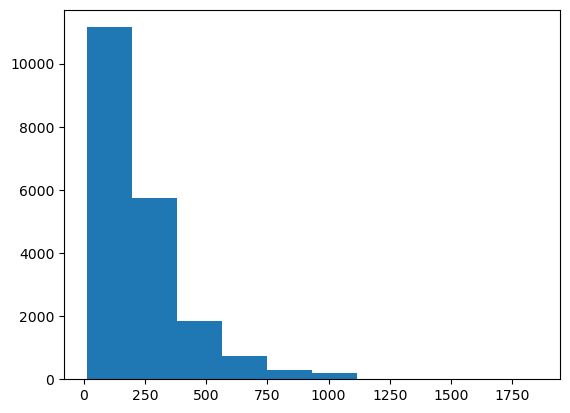

In [48]:
import matplotlib.pyplot as plt
plt.hist(lengths)

In [49]:
from keras.preprocessing.sequence import pad_sequences
train_seq = pad_sequences(train_input, maxlen=100)

In [50]:
train_seq.shape

(20000, 100)

In [51]:
print(train_seq[0])

[ 10   4  20   9   2   2   2   5  45   6   2   2  33   2   8   2 142   2
   5   2  17  73  17   2   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12   2  69   2 142  73   2   6
   2   7   2   2 188   2 103  14  31  10  10   2   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10   2 158]


In [52]:
print(train_input[0][-10:])

[6, 2, 46, 7, 14, 20, 10, 10, 2, 158]


In [53]:
print(train_seq[5])

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2   2   2 183  10
  10  13  82  79   4   2  36  71   2   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14   2  56 129   2  10  10  21   2  94   2   2   2   2  11 190
  24   2   2   7  94   2   2  10  10  87   2  34  49   2   7   2   2   2
   2   2   2   2  46  48  64  18   4   2]


In [54]:
val_seq = pad_sequences(val_input, maxlen=100)

In [55]:
import keras

model = keras.Sequential()
model.add(keras.layers.Input(shape=(100, 200)))
model.add(keras.layers.SimpleRNN(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

In [56]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 8)              │         1,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,681 (6.57 KB)

 Trainable params: 1,681 (6.57 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
train_oh = keras.utils.to_categorical(train_seq)

In [58]:
train_oh.shape

(20000, 100, 200)

In [59]:
print(np.sum(train_oh[0][0][:]))

1.0


In [60]:
val_oh = keras.utils.to_categorical(val_seq)

In [61]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 8)              │         1,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,681 (6.57 KB)

 Trainable params: 1,681 (6.57 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True)
early_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model.fit(train_oh, train_target, epochs=100, batch_size=64, callbacks=[checkpoint_cb, early_cb], validation_data=(val_oh, val_target))


Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5519 - loss: 0.6833 - val_accuracy: 0.6604 - val_loss: 0.6359
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6819 - loss: 0.6102 - val_accuracy: 0.6948 - val_loss: 0.5894
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7044 - loss: 0.5806 - val_accuracy: 0.7174 - val_loss: 0.5650
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7149 - loss: 0.5668 - val_accuracy: 0.7224 - val_loss: 0.5600
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7218 - loss: 0.5596 - val_accuracy: 0.7256 - val_loss: 0.5515
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7274 - loss: 0.5538 - val_accuracy: 0.7246 - val_loss: 0.5525
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7266 - loss: 0.5525 - val_accuracy: 0.7190 - val_loss: 0.5561
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.7272 - loss: 0.5478 - 

In [63]:
import numpy as np
best_epoch = np.argmin(history.history['val_loss']) + 1
print(best_epoch)

8


In [64]:
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)
train_input, val_input, train_target, val_target = train_test_split(train_input, train_target, random_state=42, test_size=0.2)
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [65]:
model_emb = keras.Sequential()
model_emb.add(keras.layers.Input(shape=(100,)))
model_emb.add(keras.layers.Embedding(500, 16))
model_emb.add(keras.layers.SimpleRNN(8))
model_emb.add(keras.layers.Dense(1, activation='sigmoid'))

In [66]:
model_emb.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

 Trainable params: 8,209 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
model_emb.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model_emb.fit(train_seq, train_target, epochs=20, batch_size=64, validation_data=(val_seq, val_target), callbacks=[early_cb, checkpoint_cb])

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5732 - loss: 0.6725 - val_accuracy: 0.7062 - val_loss: 0.6041
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7349 - loss: 0.5425 - val_accuracy: 0.7432 - val_loss: 0.5369
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7716 - loss: 0.4924 - val_accuracy: 0.7806 - val_loss: 0.4827
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7967 - loss: 0.4503 - val_accuracy: 0.7844 - val_loss: 0.4673
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8033 - loss: 0.4380 - val_accuracy: 0.7834 - val_loss: 0.4785
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8086 - loss: 0.4253 - val_accuracy: 0.7862 - val_loss: 0.4871
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8173 - loss: 0.4128 - val_accuracy: 0.7790 - val_loss: 0.4732


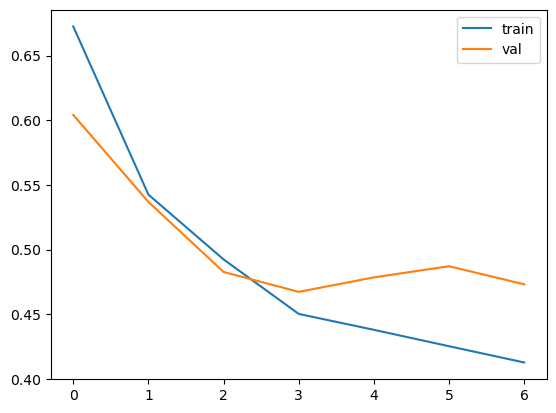

In [68]:
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'val')
plt.legend()